In [1]:
!pip install keras torch fidle tensorflow scikit-image

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 57.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 530.7/530.7 MB 62.9 MB/s  0:00:07m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.1/366.1 MB 61.9 MB/s  0:00:05m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.9/169.9 MB 65.9 MB/s  0:00:02m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.5/196.5 MB 71.6 MB/s  0:00:02m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 38.6 MB/s  0:00:01m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.3/188.3 MB 57.8 MB/s  0:00:03m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 58.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 81.4 MB/s  0:00:04m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 74.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 73.4 MB/s  0:00:01m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 

In [2]:
import s3fs
import pandas as pd
import geopandas as gpd
import torch
import matplotlib.pyplot as plt
import os
os.environ['KERAS_BACKEND'] = 'torch'

import keras
from keras import layers
import numpy as np
import tensorflow as tf

import sys
import fidle

/opt/python/lib/python3.13/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12090). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0
I0000 00:00:1777140622.073069    4518 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777140622.154423    4518 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To en

In [3]:
# =========================================================
# 1. RECHARGEMENT DU PARQUET DEPUIS MINIO
# =========================================================
MY_BUCKET = "matheo"
CHEMIN_FICHIER_OUT = "diffusion/data/fwi_se_spain_28x28.parquet"
VALUE_COL = "fwi-daily-proj"
GRID_SIZE = 28

fs = s3fs.S3FileSystem(client_kwargs={"endpoint_url": "https://minio.lab.sspcloud.fr"})
with fs.open(f"s3://{MY_BUCKET}/{CHEMIN_FICHIER_OUT}", "rb") as f:
    df_loaded = pd.read_parquet(f)

print(f"DataFrame rechargé : {df_loaded.shape}")
print(df_loaded.head())

# =========================================================
# 2. RECONSTRUCTION DU TENSEUR (N, 28, 28)
# =========================================================
# On trie par (time, lat, lon) pour retrouver exactement l'ordre du ravel
# utilisé lors de la sauvegarde. `meshgrid(se_lon_centers, se_lat_centers)`
# produit LAT variant par ligne, LON variant par colonne ; le ravel parcourt
# donc les lignes (lat fixe, lon croissante) puis les latitudes dans l'ordre
# où elles apparaissent dans se_lat_centers (croissante).
df_sorted = df_loaded.sort_values(["time", "lat", "lon"]).reset_index(drop=True)
# Normalisation min-max entre 0 et 1
X_min = df_sorted['fwi-daily-proj'].min()
X_max = df_sorted['fwi-daily-proj'].max()

df_sorted['fwi-daily-proj'] = (df_sorted['fwi-daily-proj'] - X_min) / (X_max - X_min)


# Vérification : chaque date doit avoir exactement 784 pixels
counts = df_sorted.groupby("time").size()
assert (counts == GRID_SIZE * GRID_SIZE).all(), \
    f"Certaines dates n'ont pas {GRID_SIZE*GRID_SIZE} pixels"

# Conversion en tenseur (N, 28, 28)
n_dates = df_sorted["time"].nunique()
X = df_sorted[VALUE_COL].values.reshape(n_dates, GRID_SIZE, GRID_SIZE)
dates = np.sort(df_sorted["time"].unique())

print(f"Tenseur X : {X.shape}")   # (N, 28, 28)
print(f"min = {X.min():.3f}, max = {X.max():.3f}, mean = {X.mean():.3f}")

DataFrame rechargé : (10308816, 4)
        time        lat       lon  fwi-daily-proj
0 1970-01-01  37.267857 -8.548214             1.0
1 1970-01-01  37.267857 -8.244643             1.0
2 1970-01-01  37.267857 -7.941071             1.0
3 1970-01-01  37.267857 -7.637500             1.0
4 1970-01-01  37.267857 -7.333929             1.0
Tenseur X : (13149, 28, 28)
min = 0.000, max = 1.000, mean = 0.071


# Some layer classes

In [4]:
from torch.distributions.normal import Normal

# Note : https://keras.io/guides/making_new_layers_and_models_via_subclassing/

class SamplingLayer(keras.layers.Layer):
    '''A custom layer that receive (z_mean, z_var) and sample a z vector'''

    def call(self, inputs):
        
        z_mean, z_log_var = inputs
        
        batch_size, latent_dim = z_mean.shape
        
        epsilon = Normal(0, 1).sample((batch_size, latent_dim)).to(z_mean.device)

        z = z_mean + torch.exp(0.5 * z_log_var) * epsilon 
        
        return z

In [5]:

class VariationalLossLayer(keras.layers.Layer):
   
    def __init__(self, loss_weights=[3,7]):
        super().__init__()
        self.k1 = loss_weights[0]
        self.k2 = loss_weights[1]


    def call(self, inputs):
        
        k1 = self.k1
        k2 = self.k2
        
        # ---- Retrieve inputs
        #
        x, z_mean, z_log_var, y = inputs
        
        # ---- Compute : reconstruction loss
        #                
        r_loss = torch.nn.functional.binary_cross_entropy(y, x, reduction='sum')
        
        #
        # ---- Compute : kl_loss
        # 
        kl_loss = - torch.sum(1+ z_log_var - z_mean.pow(2) - z_log_var.exp())
        
        # ---- Compute total loss, and add it
        #
        loss = r_loss*k1 + kl_loss*k2
        self.add_loss(loss)
        
        return y

    
    def get_config(self):
        return {'loss_weights':[self.k1,self.k2]}
        # To keep track of the loss weights in checkpoints and logs,
        # we need to implement get_config() so that Keras can properly serialize them.

# Parameters

In [6]:
latent_dim    = 2
loss_weights  = [1,.06]

scale         = 0.2
seed          = 123

batch_size    = 64
epochs        = 10
fit_verbosity = 1


## 2-Model
1st model

### Encoder

In [7]:
inputs    = keras.Input(shape=(28, 28, 1))
x         = layers.Conv2D(32, 3, strides=1, padding="same", activation="relu")(inputs)
x         = layers.Conv2D(64, 3, strides=2, padding="same", activation="relu")(x)
x         = layers.Conv2D(64, 3, strides=2, padding="same", activation="relu")(x)
x         = layers.Conv2D(64, 3, strides=1, padding="same", activation="relu")(x)
x         = layers.Flatten()(x)
x         = layers.Dense(16, activation="relu")(x)

z_mean    = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
z         = SamplingLayer()([z_mean, z_log_var])

encoder = keras.Model(inputs, [z_mean, z_log_var, z], name="encoder")
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 28, 28,    │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 14, 14,    │     18,496 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 7, 7, 64)  │     36,928 │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 7, 7, 64)  │     36,928 │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 3136)      │          0 │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │     50,192 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │         34 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │         34 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling_layer      │ (None, 2)         │          0 │ z_mean[0][0],     │
│ (SamplingLayer)     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 142,932 (558.33 KB)

 Trainable params: 142,932 (558.33 KB)

 Non-trainable params: 0 (0.00 B)

### Decoder

In [8]:
inputs  = keras.Input(shape=(latent_dim,))
x       = layers.Dense(7 * 7 * 64, activation="relu")(inputs)
x       = layers.Reshape((7, 7, 64))(x)
x       = layers.Conv2DTranspose(64, 3, strides=1, padding="same", activation="relu")(x)
x       = layers.Conv2DTranspose(64, 3, strides=2, padding="same", activation="relu")(x)
x       = layers.Conv2DTranspose(32, 3, strides=2, padding="same", activation="relu")(x)
outputs = layers.Conv2DTranspose(1,  3, padding="same", activation="sigmoid")(x)

decoder = keras.Model(inputs, outputs, name="decoder")

decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3136)           │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 7, 7, 64)       │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 28, 28, 1)      │           289 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,017 (398.50 KB)

 Trainable params: 102,017 (398.50 KB)

 Non-trainable params: 0 (0.00 B)

### Assembly 

In [9]:
inputs  = keras.Input(shape=(28, 28, 1))

z_mean, z_log_var, z = encoder(inputs)
outputs              = decoder(z)

outputs = VariationalLossLayer(loss_weights=loss_weights)([inputs, z_mean, z_log_var, outputs])

vae     = keras.Model(inputs,outputs)

vae.compile(optimizer='adam', loss=None)

## 3-Training

In [10]:
from keras.callbacks import Callback
import numpy as np
import matplotlib.pyplot as plt
from skimage import io
import os

class ImagesCallback(Callback):
    '''
    Save generated (random mode) or encoded/decoded (z mode) images on epoch end.
    params:
        x           : input images, for z mode (None)
        z_dim       : size of the latent space, for random mode (None)
        nb_images   : number of images to save
        from_z      : save images from z (False)
        from_random : save images from random (False)
        filename    : images filename
        run_dir     : output directory to save images        
    '''
    
   
    def __init__(self, x           = None,
                       z_dim       = None,
                       nb_images   = 5,
                       from_z      = False, 
                       from_random = False,
                       filename    = 'image-{epoch:03d}-{i:02d}.jpg',
                       run_dir     = './run'):
        
        # ---- Parameters
        #
        
        self.x = None if x is None else x[:nb_images]
        self.z_dim       = z_dim
        
        self.nb_images   = nb_images
        self.from_z      = from_z
        self.from_random = from_random

        self.filename_z       = run_dir + '/images-z/'      + filename
        self.filename_random  = run_dir + '/images-random/' + filename
        
        if from_z:      os.makedirs( run_dir + '/images-z/',     mode=0o750, exist_ok=True)
        if from_random: os.makedirs( run_dir + '/images-random/', mode=0o750, exist_ok=True)
        
    
    
    def save_images(self, images, filename, epoch):
        '''Save images as <filename>'''
        
        for i,image in enumerate(images):
            
            image = image.squeeze()  # Squeeze it if monochrome : (lx,ly,1) -> (lx,ly) 
        
            filenamei = filename.format(epoch=epoch,i=i)
            
            if len(image.shape) == 2:
                plt.imsave(filenamei, image, cmap='viridis')
            else:
                plt.imsave(filenamei, image)

    
    
    def on_epoch_end(self, epoch, logs={}):
        '''Called at the end of each epoch'''
        
        encoder     = self.model.get_layer('encoder')
        decoder     = self.model.get_layer('decoder')

        if self.from_random:
            z      = np.random.normal( size=(self.nb_images,self.z_dim) )
            images = decoder.predict(z)
            self.save_images(images, self.filename_random, epoch)
            
        if self.from_z:
            z_mean, z_var, z  = encoder.predict(self.x)
            images            = decoder.predict(z)
            self.save_images(images, self.filename_z, epoch)


    def get_images(self, epochs=None, from_z=True,from_random=True):
        '''Read and return saved images. epochs is a range'''
        if epochs is None : return
        images_z = []
        images_r = []
        for epoch in list(epochs):
            for i in range(self.nb_images):
                if from_z:
                    f = self.filename_z.format(epoch=epoch,i=i)
                    images_z.append( io.imread(f) )
                if from_random:
                    f = self.filename_random.format(epoch=epoch,i=i)
                    images_r.append( io.imread(f) )
        return images_z, images_r
            

In [11]:
class FWIImagesCallback(ImagesCallback):
    
    def __init__(self, X_min, X_max, vmin=None, vmax=None, **kwargs):
        super().__init__(**kwargs)
        self.X_min = X_min
        self.X_max = X_max
        self.vmin  = vmin  # pour une échelle de couleur cohérente entre epochs
        self.vmax  = vmax
    
    def save_images(self, images, filename, epoch):
        for i, image in enumerate(images):
            image = image.squeeze()  # (H, W, 1) → (H, W)
            
            # Dénormalisation
            image_denorm = image * (self.X_max - self.X_min) + self.X_min
            
            filenamei = filename.format(epoch=epoch, i=i)
            
            plt.imsave(filenamei, image_denorm, 
                       cmap='viridis',
                       vmin=self.vmin if self.vmin else image_denorm.min(),
                       vmax=self.vmax if self.vmax else image_denorm.max())

In [12]:
run_dir = '.'

callback_images      = ImagesCallback(x=X, z_dim=latent_dim, nb_images=5, from_z=True, from_random=True, run_dir=run_dir)

callbacks_list = [callback_images]
callback_colour = FWIImagesCallback(
    X_min      = X_min,         # sauvegardés lors de la normalisation
    X_max      = X_max,
    vmin       = 0,             # échelle fixe pour comparer entre epochs
    vmax       = X_max,
    x          = X[:5],
    z_dim      = latent_dim,
    nb_images  = 5,
    from_z     = True,
    from_random= True,
    run_dir    = './run'
)
#callbacks_list = [callback_colour]

In [13]:
chrono=fidle.Chrono()
chrono.start()

history = vae.fit(X, epochs=epochs, batch_size=batch_size, callbacks=callbacks_list, verbose=fit_verbosity)

chrono.show()

Epoch 1/10


/opt/python/lib/python3.13/site-packages/keras/src/backend/common/backend_utils.py:100: UserWarning: You might experience inconsistencies across backends when calling conv transpose with kernel_size=3, stride=2, dilation_rate=1, padding=same, output_padding=1.
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step/step - loss: 17891.588
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
206/206 ━━━━━━━━━━━━━━━━━━━━ 76s 367ms/step - loss: 13433.1494
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step/step - loss: 11103.483
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
206/206 ━━━━━━━━━━━━━━━━━━━━ 69s 332ms/step - loss: 10970.3408
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step/step - loss: 10865.998
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
206/206 ━━━━━━━━━━━━━━━━━━━━ 66s 322ms/step - loss: 10864.5586
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step/step - loss: 10829.914
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
206/206 ━━━━━━━━━━━━━━━━━━━━ 73s 354ms/step - loss: 10821.1670
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step/step - loss: 10863.323
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
206/206 ━━━━━━━━━━━━

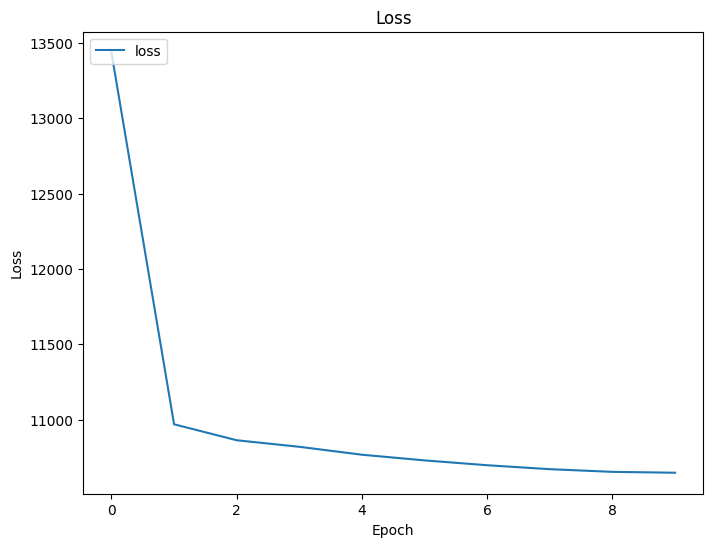

In [14]:
fidle.scrawler.history(history,  plot={"Loss":['loss']}, save_as='history')

## 4 -Visualisation

<br>**Original images :**

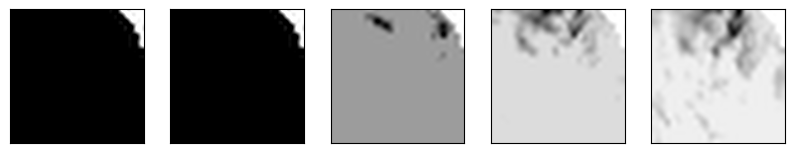

<br>**Encoded/decoded images**

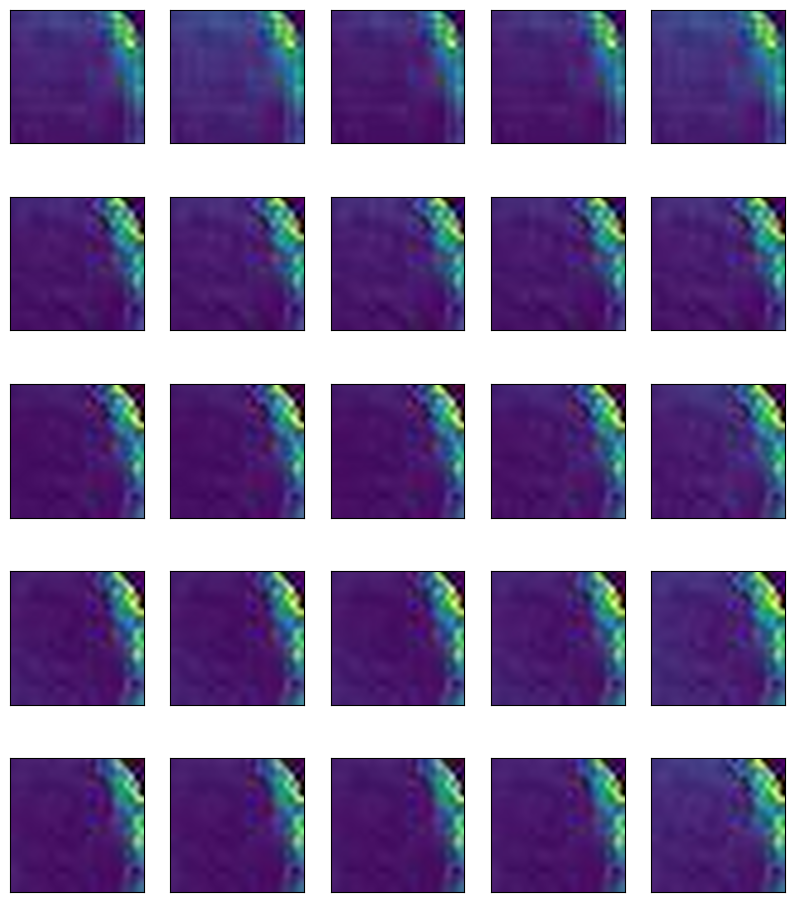

<br>**Original images :**

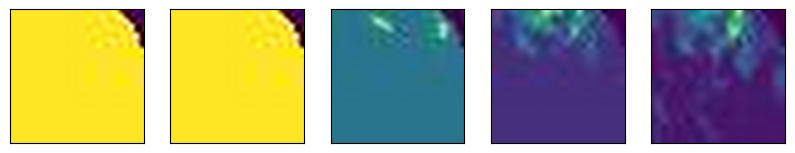

In [18]:
images_z, images_r = callback_images.get_images( range(0,epochs,2) )

fidle.utils.subtitle('Original images :')
fidle.scrawler.images(X[:5], None, indices='all', columns=5, x_size=2,y_size=2, save_as=None)

fidle.utils.subtitle('Encoded/decoded images')
fidle.scrawler.images(images_z, None, indices='all', columns=5, x_size=2,y_size=2, save_as='02-reconstruct')


X_denorm = X[:5] * (X_max - X_min) + X_min
# Sauvegarder les originaux au même format que les reconstructions
for i in range(5):
    plt.imsave(f'./run/original_{i}.jpg', 
               X_denorm[i].squeeze(), 
               cmap='viridis')
images_orig = [io.imread(f'./run/original_{i}.jpg') for i in range(5)]

fidle.utils.subtitle('Original images :')
fidle.scrawler.images(images_orig, None, indices='all', columns=5, x_size=2, y_size=2, save_as=None)

<br>**Generated images from latent space**

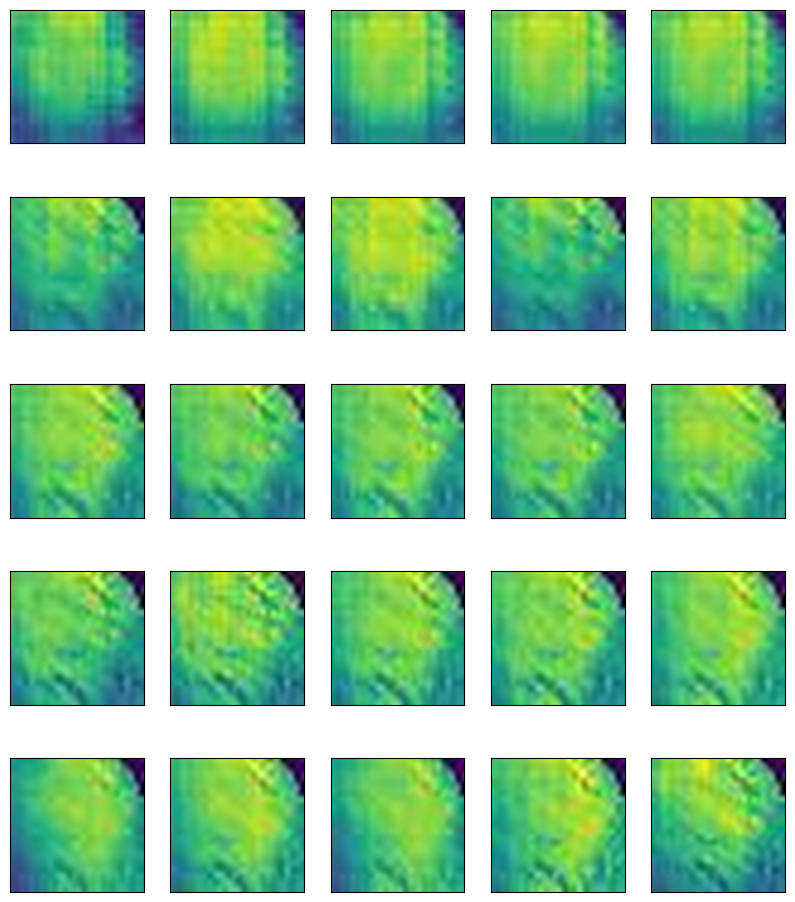

In [21]:
fidle.utils.subtitle('Generated images from latent space')
fidle.scrawler.images(images_r, None, indices='all', columns=5, x_size=2,y_size=2, save_as='03-generated')

tweaking the parameters now

In [22]:
latent_dim2    = 3
loss_weights2  = [0.7,.09]

scale         = 0.2
seed          = 123

batch_size    = 32
epochs        = 10
fit_verbosity = 1

In [23]:
inputs    = keras.Input(shape=(28, 28, 1))
x         = layers.Conv2D(32, 3, strides=1, padding="same", activation="relu")(inputs)
x         = layers.Conv2D(64, 3, strides=2, padding="same", activation="relu")(x)
x         = layers.Conv2D(64, 3, strides=2, padding="same", activation="relu")(x)
x         = layers.Conv2D(64, 3, strides=1, padding="same", activation="relu")(x)
x         = layers.Flatten()(x)
x         = layers.Dense(16, activation="relu")(x)

z_mean    = layers.Dense(latent_dim2, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim2, name="z_log_var")(x)
z         = SamplingLayer()([z_mean, z_log_var])

encoder2 = keras.Model(inputs, [z_mean, z_log_var, z], name="encoder")
#encoder.summary()

inputs  = keras.Input(shape=(latent_dim2,))
x       = layers.Dense(7 * 7 * 64, activation="relu")(inputs)
x       = layers.Reshape((7, 7, 64))(x)
x       = layers.Conv2DTranspose(64, 3, strides=1, padding="same", activation="relu")(x)
x       = layers.Conv2DTranspose(64, 3, strides=2, padding="same", activation="relu")(x)
x       = layers.Conv2DTranspose(32, 3, strides=2, padding="same", activation="relu")(x)
outputs = layers.Conv2DTranspose(1,  3, padding="same", activation="sigmoid")(x)

decoder2 = keras.Model(inputs, outputs, name="decoder")

#decoder.summary()
inputs  = keras.Input(shape=(28, 28, 1))

z_mean, z_log_var, z = encoder2(inputs)
outputs              = decoder2(z)

outputs = VariationalLossLayer(loss_weights=loss_weights2)([inputs, z_mean, z_log_var, outputs])

vae2     = keras.Model(inputs,outputs)

vae2.compile(optimizer='adam', loss=None)

run_dir = '.'

callback_images2      = ImagesCallback(x=X, z_dim=latent_dim2, nb_images=5, from_z=True, from_random=True, run_dir=run_dir)

callbacks_list2 = [callback_images2]

chrono=fidle.Chrono()
chrono.start()

history2 = vae2.fit(X, epochs=epochs, batch_size=batch_size, callbacks=callbacks_list2, verbose=fit_verbosity)

chrono.show()

Epoch 1/10


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step/step - loss: 5283.101
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
411/411 ━━━━━━━━━━━━━━━━━━━━ 125s 303ms/step - loss: 4176.4917
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step/step - loss: 3746.261
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
411/411 ━━━━━━━━━━━━━━━━━━━━ 106s 258ms/step - loss: 3735.8743
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/steps/step - loss: 3667.35
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
411/411 ━━━━━━━━━━━━━━━━━━━━ 101s 246ms/step - loss: 3690.0029
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step/step - loss: 3668.62
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
411/411 ━━━━━━━━━━━━━━━━━━━━ 98s 239ms/step - loss: 3680.5750
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step/step - loss: 3680.167
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
411/411 ━━━━━━━━━━━━━━━━━━━━ 

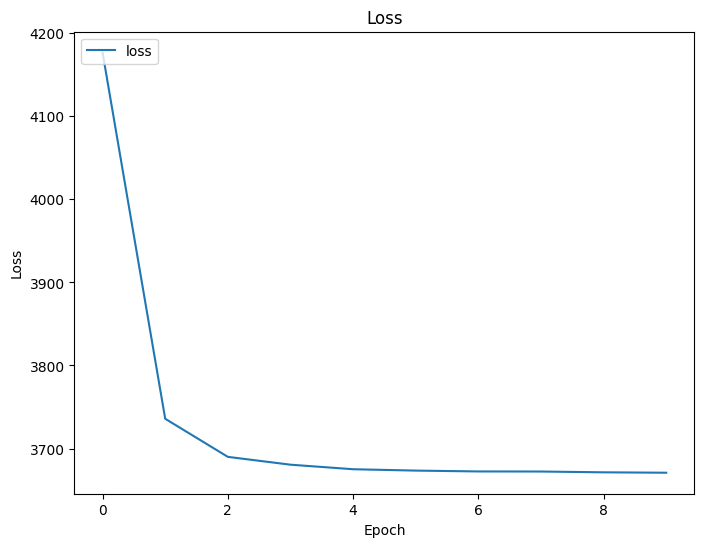

In [24]:
fidle.scrawler.history(history2,  plot={"Loss":['loss']}, save_as='history2')

<br>**Original images :**

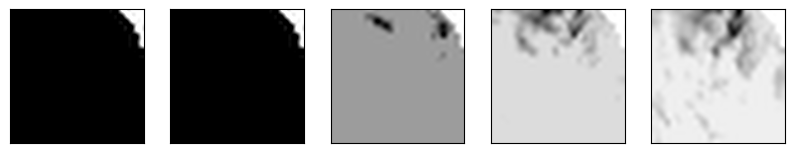

<br>**Encoded/decoded images**

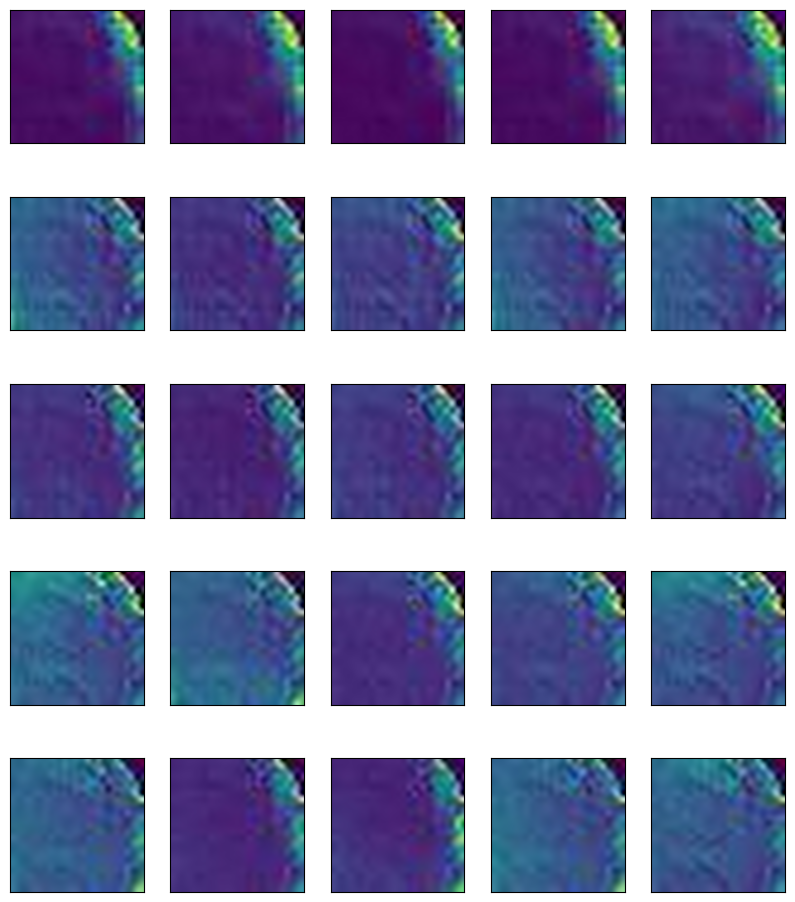

<br>**Original images :**

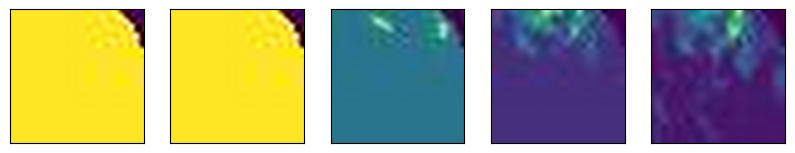

In [26]:
images_z, images_r = callback_images2.get_images( range(0,epochs,2) )

fidle.utils.subtitle('Original images :')
fidle.scrawler.images(X[:5], None, indices='all', columns=5, x_size=2,y_size=2, save_as=None)

fidle.utils.subtitle('Encoded/decoded images')
fidle.scrawler.images(images_z, None, indices='all', columns=5, x_size=2,y_size=2, save_as='02-reconstruct')


X_denorm = X[:5] * (X_max - X_min) + X_min
# Sauvegarder les originaux au même format que les reconstructions
for i in range(5):
    plt.imsave(f'./run/original_{i}.jpg', 
               X_denorm[i].squeeze(), 
               cmap='viridis')
images_orig = [io.imread(f'./run/original_{i}.jpg') for i in range(5)]

fidle.utils.subtitle('Original images :')
fidle.scrawler.images(images_orig, None, indices='all', columns=5, x_size=2, y_size=2, save_as=None)

<br>**Generated images from latent space**

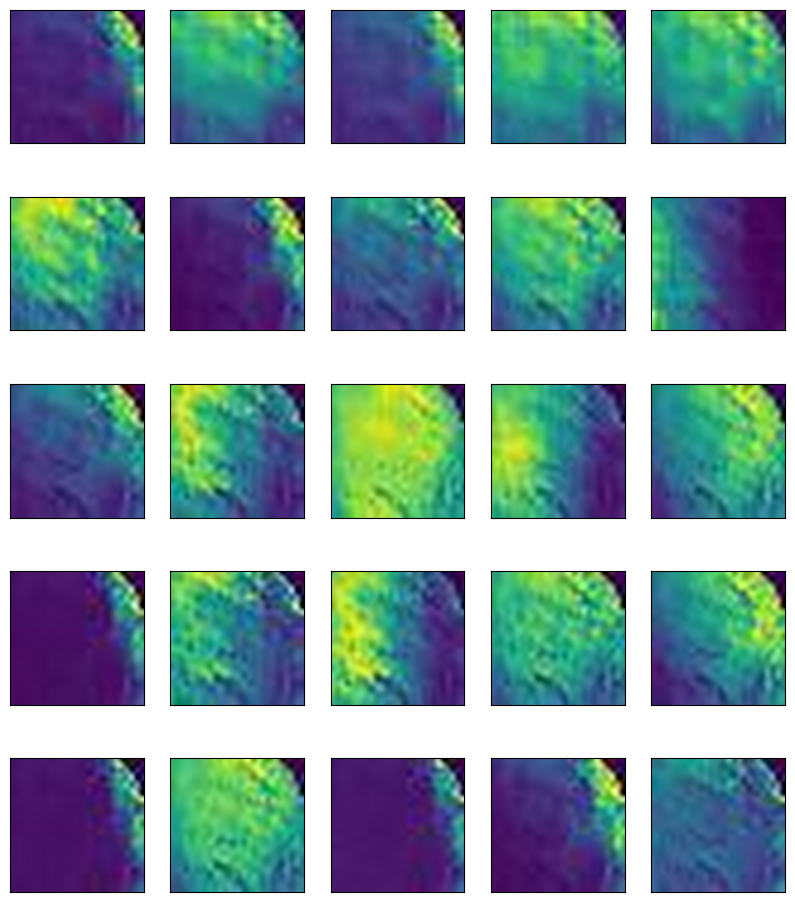

In [27]:
fidle.utils.subtitle('Generated images from latent space')
fidle.scrawler.images(images_r, None, indices='all', columns=5, x_size=2,y_size=2, save_as='03-generated')